# Description

# Modules

In [1]:
import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from data.recount2 import LVAnalysis
from utils import chunker
import conf

# Settings

Specify below the LV id you are interested in:

In [2]:
LV_NAME = "LV24"

# Paths

These are paths to folder and files where we'll save our figures.

In [3]:
OUTPUT_FIGURES_DIR = Path(conf.RESULTS_DIR, "demo", f"{LV_NAME.lower()}").resolve()
display(OUTPUT_FIGURES_DIR)
OUTPUT_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

PosixPath('/opt/data/results/demo/lv24')

In [4]:
OUTPUT_CELL_TYPE_FILEPATH = OUTPUT_FIGURES_DIR / f"{LV_NAME.lower()}-cell_types.svg"
display(OUTPUT_CELL_TYPE_FILEPATH)

PosixPath('/opt/data/results/demo/lv24/lv24-cell_types.svg')

# Load MultiPLIER summary

In [5]:
multiplier_model_summary = pd.read_pickle(conf.MULTIPLIER["MODEL_SUMMARY_FILE"])

In [6]:
multiplier_model_summary.shape

(2157, 5)

In [7]:
multiplier_model_summary.head()

,pathway,LV index,AUC,p-value,FDR
1,KEGG_LYSINE_DEGRADATION,1,0.388059,0.866078,0.956005
2,REACTOME_MRNA_SPLICING,1,0.733057,0.000048,0.000582
3,MIPS_NOP56P_ASSOCIATED_PRE_RRNA_COMPLEX,1,0.680555,0.001628,0.011366
4,KEGG_DNA_REPLICATION,1,0.549473,0.312155,0.539951
5,PID_MYC_ACTIVPATHWAY,1,0.639303,0.021702,0.083739


# Load LV data

You can use the `LVAnalysis` class to explore an LV.

In [9]:
lv_obj = LVAnalysis(LV_NAME)

Here I show the top 20 genes for our LV. You can see gene symbols, the LV weight (in column `LV603`) and the cytoband.

In [10]:
lv_obj.lv_genes.head(20)

,gene_name,LV24,gene_band
0,KCNK7,5.501678,11q13.1
1,KRT1,5.084971,12q13.13
2,ACER1,4.931350,19p13.3
3,ASPRV1,4.901245,2p13.3
4,CDHR1,4.253085,10q23.1
5,CTNNBIP1,3.859810,1p36.22
6,CAPNS2,3.379442,16q12.2
7,ELOVL3,3.331303,10q24.32
8,KLC3,3.326713,19q13.32
9,DSP,3.114874,6p24.3


In [17]:
print(" ".join(lv_obj.lv_genes.head(50)["gene_name"].tolist()))

KCNK7 KRT1 ACER1 ASPRV1 CDHR1 CTNNBIP1 CAPNS2 ELOVL3 KLC3 DSP EVPL PERP JUP KRT5 WNT4 SULT2B1 EFNA3 EPHB6 DSC1 TMEM45A CD207 TGM5 ALDH3B2 EEF2K COL17A1 GJB5 PPP1R13L AQP3 RARG DEGS1 SPTBN2 PARD6G SLC46A2 GSN ALOX15B FADS2 KREMEN1 MAP3K6 TP63 NOTCH3 EXOSC7 BARX2 SFN TNFRSF19 SLC6A9 SFRP2 BLMH RORA MAPK13 KLF4


In [16]:
print("\n".join(lv_obj.lv_genes.head(50)["gene_name"].tolist()))

KCNK7
KRT1
ACER1
ASPRV1
CDHR1
CTNNBIP1
CAPNS2
ELOVL3
KLC3
DSP
EVPL
PERP
JUP
KRT5
WNT4
SULT2B1
EFNA3
EPHB6
DSC1
TMEM45A
CD207
TGM5
ALDH3B2
EEF2K
COL17A1
GJB5
PPP1R13L
AQP3
RARG
DEGS1
SPTBN2
PARD6G
SLC46A2
GSN
ALOX15B
FADS2
KREMEN1
MAP3K6
TP63
NOTCH3
EXOSC7
BARX2
SFN
TNFRSF19
SLC6A9
SFRP2
BLMH
RORA
MAPK13
KLF4


Show the pathways our LV is aligned to (neutrophils):

In [10]:
multiplier_model_summary[
    multiplier_model_summary["LV index"].isin((LV_NAME[2:],))
    & (
        (multiplier_model_summary["FDR"] < 0.05)
        & (multiplier_model_summary["AUC"] >= 0.75)
    )
]

[2025-01-29 16:57:31,104 - numexpr.utils] INFO: Note: NumExpr detected 32 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 8.
[2025-01-29 16:57:31,104 - numexpr.utils] INFO: NumExpr defaulting to 8 threads.


,pathway,LV index,AUC,p-value,FDR
130,PID_DELTANP63PATHWAY,24,0.783682,0.001222,0.00906


Here I load the LV metadata.
This is, for each sample from our matrix B, we load its metadata.
The `LVAnalysis` class takes care of downloading all necessary files from recount2.

In [11]:
lv_data = lv_obj.get_experiments_data()

SRP035864, SRP035988, SRP050971, SRP026042, SRP057087, SRP021891, SRP014146, SRP052740, SRP043085, SRP065812, SRP033135, SRP009251, SRP060416, SRP010678, SRP042620, SRP017575, SRP055569, SRP042161, SRP058773, SRP006575, SRP065445, SRP016583, SRP052856, SRP014320, 

/opt/code/libs/data/recount2.py:323: UserWarning: Not all experiments data could be loaded (23 != 24)
  warnings.warn(


In [12]:
lv_data.shape

(3566, 40)

In [13]:
lv_data.head()

treatment tissue tissue type patient patient id gender  \
project   run                                                                 
SRP035864 SRR1145042       UVB   skin         NaN     NaN        NaN    NaN   
          SRR1145043       UVB   skin         NaN     NaN        NaN    NaN   
          SRR1145044       UVB   skin         NaN     NaN        NaN    NaN   
          SRR1145045       UVB   skin         NaN     NaN        NaN    NaN   
          SRR1145046       UVB   skin         NaN     NaN        NaN    NaN   

                      age tissue/treatment id group subjects  ... prognosis  \
project   run                                                 ...             
SRP035864 SRR1145042  NaN                 NaN   NaN      NaN  ...       NaN   
          SRR1145043  NaN                 NaN   NaN      NaN  ...       NaN   
          SRR1145044  NaN                 NaN   NaN      NaN  ...       NaN   
          SRR1145045  NaN                 NaN   NaN      NaN  ...       NaN   
          SRR1145046  NaN                 NaN   NaN      NaN  ...       NaN   

                     cell line subtype well number  \
project   run                                        
SRP035864 SRR1145042       NaN     NaN         NaN   
          SRR1145043       NaN     NaN         NaN   
          SRR1145044       NaN     NaN         NaN   
          SRR1145045       NaN     NaN         NaN   
          SRR1145046       NaN     NaN         NaN   

                     reprogramming time point (day) developmental stage  \
project   run                                                             
SRP035864 SRR1145042                            NaN                 NaN   
          SRR1145043                            NaN                 NaN   
          SRR1145044                            NaN                 NaN   
          SRR1145045                            NaN                 NaN   
          SRR1145046                            NaN                 NaN   

                     disease status diagnosis growth conditions      LV24  
project   run                                                              
SRP035864 SRR1145042            NaN       NaN               NaN  0.526173  
          SRR1145043            NaN       NaN               NaN  0.442285  
          SRR1145044            NaN       NaN               NaN  0.395936  
          SRR1145045            NaN       NaN               NaN  0.316462  
          SRR1145046            NaN       NaN               NaN  0.349480  

[5 rows x 40 columns]

# LV cell types analysis

## Get top attributes

Here I quickly show the top attributes in our metadata for which we have the largest LV variance.
This is just to have an idea of the variance across different attributes

In [14]:
lv_attrs = lv_obj.get_attributes_variation_score()
display(lv_attrs.head(20))

patient                                    0.132075
treatment                                  0.128854
group                                      0.126801
gender                                     0.124774
age                                        0.113823
tissue/treatment id                        0.113823
tissue type                                0.113683
tissue                                     0.080025
patient id                                 0.036987
response to smoothened (smo) inhibitors    0.035944
day of differentiation                     0.030759
subject status                             0.028648
mapki sensitivity                          0.024978
mapki treatment                            0.024978
parasite                                   0.021734
clinical form                              0.021734
age group                                  0.019295
time point                                 0.017572
growth conditions                          0.016845
diagnosis   

Since we are interested in cell types and tissues, the code below will find which attributes contain "cell type" or "tissue", so we can select from these results.

In [15]:
# show those with cell type or tissue in their name
_tmp = pd.Series(lv_attrs.index)
lv_attrs[
    _tmp.str.match(
        "(?:cell.*(type|line)$)|(?:tissue$)|(?:tissue.*type$)",
        case=False,
        flags=re.IGNORECASE,
    ).values
].sort_values(ascending=False)

tissue type    0.113683
tissue         0.080025
cell type      0.003662
cell line      0.002098
dtype: float64

Select from the output above those you are interested in. Usually all of them.

In [16]:
lv_attrs_selected = [
    "tissue/treatment id",
    "tissue type",
    "tissue",
]

In [17]:
_tmp = lv_data.loc[
    :,
    lv_attrs_selected + [LV_NAME],
]

In [18]:
_tmp_seq = list(chunker(_tmp.sort_values(LV_NAME, ascending=False), 25))

Now that we selected attributes that might be providing information about the cell type, we can see which are the top ones.

If you change the number in the cell below, you can paginate over the entire set of results; for example, with `_tmp_seq[1]` you'll see the next "page" in a descending order with respect to the LV value. So the ones at the top are the most important ones.

In [19]:
_tmp_seq[0]

tissue/treatment id      tissue type  \
project   run                                               
SRP035864 SRR1145049                 NaN              NaN   
SRP035988 SRR1146248                 NaN      normal skin   
SRP050971 SRR1698137                 NaN      normal skin   
SRP035864 SRR1145047                 NaN              NaN   
SRP026042 SRR901225                    1              NaN   
SRP050971 SRR1698172                 NaN      normal skin   
          SRR1698173                 NaN      normal skin   
SRP057087 SRR1970416                 NaN              NaN   
          SRR1970420                 NaN              NaN   
SRP035988 SRR1146249                 NaN      normal skin   
          SRR1146146                 NaN      normal skin   
SRP035864 SRR1145050                 NaN              NaN   
SRP050971 SRR1698141                 NaN      normal skin   
SRP035864 SRR1145048                 NaN              NaN   
SRP050971 SRR1698134                 NaN      normal skin   
          SRR1698135                 NaN      normal skin   
          SRR1698136                 NaN      normal skin   
SRP021891 SRR836000                  NaN              NaN   
SRP050971 SRR1698167                 NaN  Uninvolved skin   
SRP026042 SRR901185                    5              NaN   
          SRR901169                    5              NaN   
SRP035988 SRR1146246                 NaN      normal skin   
SRP057087 SRR1970418                 NaN              NaN   
SRP026042 SRR1382100                   5              NaN   
          SRR901193                    5              NaN   

                                                        tissue      LV24  
project   run                                                             
SRP035864 SRR1145049                                      skin  1.519073  
SRP035988 SRR1146248                                       NaN  1.404224  
SRP050971 SRR1698137                                       NaN  1.387150  
SRP035864 SRR1145047                                      skin  1.380989  
SRP026042 SRR901225                                    Healthy  1.376663  
SRP050971 SRR1698172                                       NaN  1.372574  
          SRR1698173                                       NaN  1.372336  
SRP057087 SRR1970416                                       NaN  1.337396  
          SRR1970420                                       NaN  1.328275  
SRP035988 SRR1146249                                       NaN  1.314768  
          SRR1146146                                       NaN  1.303178  
SRP035864 SRR1145050                                      skin  1.297412  
SRP050971 SRR1698141                                       NaN  1.291499  
SRP035864 SRR1145048                                      skin  1.274616  
SRP050971 SRR1698134                                       NaN  1.267954  
          SRR1698135                                       NaN  1.264631  
          SRR1698136                                       NaN  1.260249  
SRP021891 SRR836000   skin (epidermal suction blister samples)  1.238848  
SRP050971 SRR1698167                                       NaN  1.230030  
SRP026042 SRR901185                                  Nonlesion  1.218949  
          SRR901169                                  Nonlesion  1.216933  
SRP035988 SRR1146246                                       NaN  1.216431  
SRP057087 SRR1970418                                       NaN  1.215959  
SRP026042 SRR1382100                                 Nonlesion  1.212818  
          SRR901193                                  Nonlesion  1.210343

You can see above that the RNA-seq samples are from neutrophils or granulocytes.
If we move to the next "page", we'll see this:

In [20]:
_tmp_seq[1]

tissue/treatment id              tissue type  \
project   run                                                       
SRP035988 SRR1146244                 NaN              normal skin   
SRP026042 SRR901161                    5                      NaN   
          SRR901229                    1                      NaN   
SRP035988 SRR1146191                 NaN              normal skin   
          SRR1146243                 NaN              normal skin   
          SRR1146238                 NaN              normal skin   
          SRR1146131                 NaN              normal skin   
SRP057087 SRR1970398                 NaN                      NaN   
          SRR1970410                 NaN                      NaN   
SRP050971 SRR1698164                 NaN          Uninvolved skin   
SRP057087 SRR1970412                 NaN                      NaN   
SRP050971 SRR1698168                 NaN          Uninvolved skin   
SRP035988 SRR1146186                 NaN              normal skin   
SRP050971 SRR1698166                 NaN          Uninvolved skin   
          SRR1698158                 NaN          Uninvolved skin   
          SRR1698150                 NaN          Uninvolved skin   
          SRR1698156                 NaN          Uninvolved skin   
SRP035988 SRR1146171                 NaN              normal skin   
          SRR1146230                 NaN              normal skin   
          SRR1146247                 NaN              normal skin   
SRP021891 SRR835999                  NaN                      NaN   
SRP026042 SRR901201                    5                      NaN   
SRP035988 SRR1146096                 NaN              normal skin   
SRP050971 SRR1698157                 NaN          Uninvolved skin   
SRP035988 SRR1146217                 NaN  lesional psoriatic skin   

                                                        tissue      LV24  
project   run                                                             
SRP035988 SRR1146244                                       NaN  1.201108  
SRP026042 SRR901161                                  Nonlesion  1.199438  
          SRR901229                                    Healthy  1.190844  
SRP035988 SRR1146191                                       NaN  1.184670  
          SRR1146243                                       NaN  1.179124  
          SRR1146238                                       NaN  1.164314  
          SRR1146131                                       NaN  1.157228  
SRP057087 SRR1970398                                       NaN  1.156435  
          SRR1970410                                       NaN  1.149749  
SRP050971 SRR1698164                                       NaN  1.148879  
SRP057087 SRR1970412                                       NaN  1.145804  
SRP050971 SRR1698168                                       NaN  1.144609  
SRP035988 SRR1146186                                       NaN  1.143780  
SRP050971 SRR1698166                                       NaN  1.139603  
          SRR1698158                                       NaN  1.132135  
          SRR1698150                                       NaN  1.120137  
          SRR1698156                                       NaN  1.117453  
SRP035988 SRR1146171                                       NaN  1.115498  
          SRR1146230                                       NaN  1.115398  
          SRR1146247                                       NaN  1.110100  
SRP021891 SRR835999   skin (epidermal suction blister samples)  1.108754  
SRP026042 SRR901201                                  Nonlesion  1.108477  
SRP035988 SRR1146096                                       NaN  1.101081  
SRP050971 SRR1698157                                       NaN  1.098079  
SRP035988 SRR1146217                                       NaN  1.093315

Although the attributes we selected (`cell type`, `celltype` and `tissue`) seem to be enough for most of the RNA-seq samples to get their cell types, this is not the case for some of them. For example, we have empty values (NaN) for `SRP015360`.

You can explore the metadata provided for a particular SPR with the code below. Let's see what we have in `SRP015360`:

In [ ]:
# list the top 10 samples from this project
lv_data.loc[["SRP015360"]].dropna(how="all", axis=1).sort_values(
    LV_NAME, ascending=False
).head(10)

So for `SRP015360` we only have three attributes: `age`, `Sex` and `treatment`. No cell type information. Here you can start grasping the challenges in analyzing this data.

If you are really interested in this metadata for this project, you can use this URL:
```
https://trace.ncbi.nlm.nih.gov/Traces/sra/?study=SRP015360
```
where you can put the SRP code you want. If you check the URL above, you'll see that these samples were taken from neutrophils as well (treated with different stimuli), although we don't have metadata about the cell type/tissue.

Ok, we do not want several attributes conveying the same information (cell types), just a single one, so here we'll combine the attributes we found before with a particular _order_.
In this case I select `cell type` _first_ (the order is important), `celltype` as second, and `tissue` as third/last.
This means that I will use the information in `cell type` first, but if this is empty (as in `SRP045500`), we'll try with `celltype`, and so on.

In [22]:
SELECTED_ATTRIBUTES = [
    "tissue/treatment id",
    "tissue type",
    "tissue",
]

## Get a single attribute with "cell type/tissue" information

In [23]:
plot_data = lv_data.loc[:, SELECTED_ATTRIBUTES + [LV_NAME]]

In [24]:
# if blank/nan, fill cell type column with tissue content
_new_column = plot_data[SELECTED_ATTRIBUTES].fillna(method="backfill", axis=1)[
    SELECTED_ATTRIBUTES[0]
]
plot_data[SELECTED_ATTRIBUTES[0]] = _new_column
plot_data = plot_data.drop(columns=SELECTED_ATTRIBUTES[1:])
plot_data = plot_data.fillna({SELECTED_ATTRIBUTES[0]: "NOT CATEGORIZED"})

In [25]:
plot_data = plot_data.sort_values(LV_NAME, ascending=False)

In [26]:
plot_data.head(20)

tissue/treatment id      LV24
project   run                                                           
SRP035864 SRR1145049                                      skin  1.519073
SRP035988 SRR1146248                               normal skin  1.404224
SRP050971 SRR1698137                               normal skin  1.387150
SRP035864 SRR1145047                                      skin  1.380989
SRP026042 SRR901225                                          1  1.376663
SRP050971 SRR1698172                               normal skin  1.372574
          SRR1698173                               normal skin  1.372336
SRP057087 SRR1970416                           NOT CATEGORIZED  1.337396
          SRR1970420                           NOT CATEGORIZED  1.328275
SRP035988 SRR1146249                               normal skin  1.314768
          SRR1146146                               normal skin  1.303178
SRP035864 SRR1145050                                      skin  1.297412
SRP050971 SRR1698141                               normal skin  1.291499
SRP035864 SRR1145048                                      skin  1.274616
SRP050971 SRR1698134                               normal skin  1.267954
          SRR1698135                               normal skin  1.264631
          SRR1698136                               normal skin  1.260249
SRP021891 SRR836000   skin (epidermal suction blister samples)  1.238848
SRP050971 SRR1698167                           Uninvolved skin  1.230030
SRP026042 SRR901185                                          5  1.218949

You can see that now all attributes ("celltype", "cell type" and "tissue") are combined under a single attribute named "cell type".
For example, if you look at `SRP045500`, which had a value under "celltype" but an empty (NaN) value for attribute "cell type", that now the value was moved to "cell type" (it was unified into this single attribute).

If you see "NOT CATEGORIZED", it means that none of the attributes you used had a value (they were all empty or NaN). In this case you would go the URL before and read the article/RNA-seq data description to find out the cell type or tissue (or whatever attribute your are interested in).

## Standardize cell type names

When cell type values are different but represent the same cell type, we unify them:

In [27]:
final_plot_data = plot_data.replace(
    {
        SELECTED_ATTRIBUTES[0]: {
            # # neutrophils:
            # "primary human neutrophils": "Neutrophils",
            # "Neutrophil isolated from peripheral blood": "Neutrophils",
            # "Neutrophil": "Neutrophils",
            # "neutrophils (Neu)": "Neutrophils",
            # # granulocytes:
            # "granulocyte": "Granulocytes",
            # # monocytes:
            # "primary human monocytes": "Monocytes",
            # # whole blood:
            # #             "whole blood": "Whole blood",  # uncomment this line to merge occurences of "whole blood" into "Whole blood"
            # "Whole Blood": "Whole blood",
            # # PBMC:
            # "primary human PBMC": "PBMC",
            # # B-cells:
            # "primary human B cells": "B cells",
            # # T-cells:
            # "primary human T cells": "T cells",
            # # epithelial cells:
            # "epithelial cells (Epi)": "Epithelial cells",
            # "primary human myeloid DC": "mDCs",
        }
    }
)

The code below is more advanced, but you can use it to customize even further your final attribute value (for example, if you want to use the cell type, but put the treatment name with parenthesis).

In [28]:
# # add also tissue information to these projects
# _srp_code = "SRP061881"
# _tmp = final_plot_data.loc[(_srp_code,)].apply(
#     lambda x: lv_data.loc[(_srp_code, x.name), "cell type"]
#     + f" ({lv_data.loc[(_srp_code, x.name), 'tissue']})",
#     axis=1,
# )
# final_plot_data.loc[(_srp_code, _tmp.index), SELECTED_ATTRIBUTES[0]] = _tmp.values

In [29]:
# # all samples from SRP015360 are neutrophils
# final_plot_data[SELECTED_ATTRIBUTES[0]] = final_plot_data.apply(
#     lambda x: "Neutrophils" if x.name[0] in ("SRP015360",) else x[SELECTED_ATTRIBUTES[0]],
#     axis=1,
# )

In [30]:
final_plot_data = final_plot_data.sort_values(LV_NAME, ascending=False)

## Threshold LV values

The code below is useful in case you want to put a threshold to the plot (for example, you have same samples with very high values).

In [31]:
# final_plot_data.loc[
#     final_plot_data[LV_NAME] > LV_AXIS_THRESHOLD, LV_NAME
# ] = LV_AXIS_THRESHOLD

## Delete samples with no tissue/cell type information

If you are not interested in samples for which we couldn't find cell type/tissue information, you can delete them by uncommenting the code below.
However, if you want, you can take a look at those later (we'll show you how at the end).

In [32]:
# final_plot_data = final_plot_data[
#     final_plot_data[SELECTED_ATTRIBUTE] != "NOT CATEGORIZED"
# ]

## Set top cell types to show

In [33]:
N_TOP_ATTRS = 10

In [34]:
attr_order = (
    final_plot_data.groupby(SELECTED_ATTRIBUTES[0])
    .max()
    .sort_values(LV_NAME, ascending=False)
    .index[:N_TOP_ATTRS]
    .tolist()
)

In [35]:
len(attr_order)

10

In [36]:
attr_order[:5]

['skin',
 'normal skin',
 '1',
 'NOT CATEGORIZED',
 'skin (epidermal suction blister samples)']

# Plot

Now we create the plot with RNA-seq samples as points, cell types in the x-axis, and the LV value in the y-axis.
This shows you in which cell types genes in LV603 are primirily expressed.

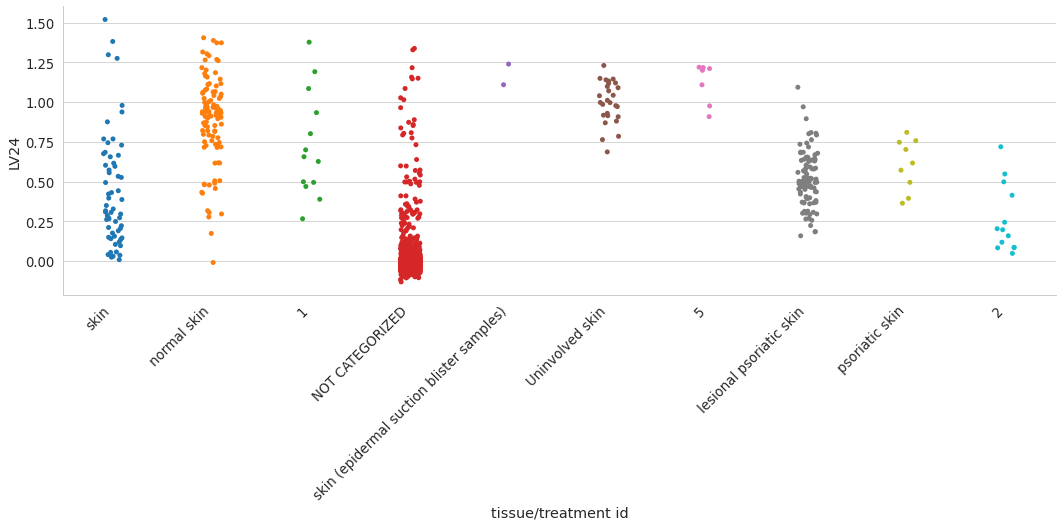

In [37]:
with sns.plotting_context("paper", font_scale=1.5), sns.axes_style("whitegrid"):
    sns.catplot(
        data=final_plot_data,
        y=LV_NAME,
        x=SELECTED_ATTRIBUTES[0],
        order=attr_order,
        kind="strip",
        height=5,
        aspect=3,
    )
    plt.xticks(rotation=45, horizontalalignment="right")

    # You can save the figure if you uncomment the code below
    # the figure will be created under ${DATA_FOLDER}/results/demo

#     plt.savefig(
#         OUTPUT_CELL_TYPE_FILEPATH,
#         bbox_inches="tight",
#         facecolor="white",
#     )

# Debug

Now that you have the figure for your LV, you can debug some things.
For example, you'll see above that some samples are "NOT CATEGORIZED".
Let's see which are those:

In [43]:
with pd.option_context(
    "display.max_rows", None, "display.max_columns", None, "display.max_colwidth", None
):
    _tmp = final_plot_data[
        final_plot_data[SELECTED_ATTRIBUTES[0]].str.contains("normal skin")
    ]
    display(_tmp.head(20))

tissue/treatment id      LV24
project   run                                     
SRP035988 SRR1146248         normal skin  1.404224
SRP050971 SRR1698137         normal skin  1.387150
          SRR1698172         normal skin  1.372574
          SRR1698173         normal skin  1.372336
SRP035988 SRR1146249         normal skin  1.314768
          SRR1146146         normal skin  1.303178
SRP050971 SRR1698141         normal skin  1.291499
          SRR1698134         normal skin  1.267954
          SRR1698135         normal skin  1.264631
          SRR1698136         normal skin  1.260249
SRP035988 SRR1146246         normal skin  1.216431
          SRR1146244         normal skin  1.201108
          SRR1146191         normal skin  1.184670
          SRR1146243         normal skin  1.179124
          SRR1146238         normal skin  1.164314
          SRR1146131         normal skin  1.157228
          SRR1146186         normal skin  1.143780
          SRR1146171         normal skin  1.115498
          SRR1146230         normal skin  1.115398
          SRR1146247         normal skin  1.110100

We don't have information about cell type/tissue for these.
But we can manually go to the URL showed before and check out.
For example, for `SRP015360` we can open our browser with this URL:
https://trace.ncbi.nlm.nih.gov/Traces/sra/?study=SRP015360, and see that the samples were taken from neutrophils.

If you need to see which information is provided by each SRP, you can again use the code below:

In [45]:
# what is there in these projects?
lv_data.loc[["SRP050971"]].dropna(how="all", axis=1).sort_values(
    LV_NAME, ascending=False
).head(60)

tissue type      LV24
project   run                                  
SRP050971 SRR1698137      normal skin  1.387150
          SRR1698172      normal skin  1.372574
          SRR1698173      normal skin  1.372336
          SRR1698141      normal skin  1.291499
          SRR1698134      normal skin  1.267954
          SRR1698135      normal skin  1.264631
          SRR1698136      normal skin  1.260249
          SRR1698167  Uninvolved skin  1.230030
          SRR1698164  Uninvolved skin  1.148879
          SRR1698168  Uninvolved skin  1.144609
          SRR1698166  Uninvolved skin  1.139603
          SRR1698158  Uninvolved skin  1.132135
          SRR1698150  Uninvolved skin  1.120137
          SRR1698156  Uninvolved skin  1.117453
          SRR1698157  Uninvolved skin  1.098079
          SRR1698148  Uninvolved skin  1.090180
          SRR1698169  Uninvolved skin  1.070239
          SRR1698162  Uninvolved skin  1.043075
          SRR1698143  Uninvolved skin  1.039714
          SRR1698147      normal skin  1.022728
          SRR1698155  Uninvolved skin  1.010876
          SRR1698146  Uninvolved skin  0.997183
          SRR1698159  Uninvolved skin  0.996384
          SRR1698154  Uninvolved skin  0.985378
          SRR1698151  Uninvolved skin  0.977452
          SRR1698170  Uninvolved skin  0.971586
          SRR1698174      normal skin  0.945681
          SRR1698144  Uninvolved skin  0.929046
          SRR1698161  Uninvolved skin  0.917424
          SRR1698163  Uninvolved skin  0.914323
          SRR1698153  Uninvolved skin  0.907799
          SRR1698171  Uninvolved skin  0.880080
          SRR1698152  Uninvolved skin  0.869475
          SRR1698176   psoriatic skin  0.809515
          SRR1698160  Uninvolved skin  0.784774
          SRR1698145  Uninvolved skin  0.763852
          SRR1698177   psoriatic skin  0.756839
          SRR1698175   psoriatic skin  0.747146
          SRR1698142   psoriatic skin  0.701814
          SRR1698149  Uninvolved skin  0.686496
          SRR1698178   psoriatic skin  0.616758
          SRR1698165   psoriatic skin  0.571658
          SRR1698139   psoriatic skin  0.495109
          SRR1698138   psoriatic skin  0.394583
          SRR1698140   psoriatic skin  0.363889

Now you can go back to section `Standardize cell type names` in this notebook and adjust according to this findings to improve the figure.
Once you are happy, you can remove the `NOT CATEGORIZED` items by uncommenting the code in `Delete samples with no tissue/cell type information`.